In [1]:
import torch 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymatgen.core import Structure
from cdft.dft3d import dft_core
from cdft.lj_eos import lj_eos

torch.set_default_dtype(torch.float64)
device = torch.device('cuda')

In [2]:
sigma = 3.73
epsilon = 148.0
parameters = {'sigma':sigma, 'epsilon':epsilon}

In [3]:
structure = Structure.from_file('structures/MIL-53(Al)ht.cif')
structure.make_supercell([4,2,2])
print('formula:        ', structure.formula)
print('num_sites:      ', structure.num_sites)
print('lattice_lengths:', structure.lattice.lengths)

formula:         Al64 H320 C512 O320
num_sites:       1216
lattice_lengths: (26.54, 33.68, 25.6)


/home/lucas/miniforge3/envs/torch/lib/python3.14/site-packages/pymatgen/io/cif.py:1029: UserWarning: No _symmetry_equiv_pos_as_xyz type key found. Spacegroup from _space_group_name_H-M_alt used.
  self.symmetry_operations = self.get_symops(data)  # type:ignore[assignment]
/home/lucas/miniforge3/envs/torch/lib/python3.14/site-packages/pymatgen/io/cif.py:1314: UserWarning: Cannot determine chemical composition from CIF! could not convert string to float: '-'
  if struct := self._get_structure(data, primitive, symmetrized, check_occu=check_occu):
/home/lucas/miniforge3/envs/torch/lib/python3.14/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: No _symmetry_equiv_pos_as_xyz type key found. Spacegroup from _space_group_name_H-M_alt used.
  struct = parser.parse_structures(primitive=primitive)[0]


In [4]:
T = 196.0
system_size = np.array([l for l in structure.lattice.lengths])
points = np.array([64, 64, 64])
dft = dft_core(parameters=parameters, temperature=T, system_size=system_size, angles=None, points=points, device=device)
dft.cell_size

array([0.4146875, 0.52625  , 0.4      ])

In [5]:
forcefield = pd.DataFrame()
forcefield['type'] = ['Al','H','C','O']
forcefield['sigma'] = np.array([3.91105, 2.84642, 3.47299, 3.03315])
forcefield['epsilon'] = np.array([155.998, 7.64893, 47.8562, 48.1581])

def lj_potential(r,sigma,epsilon):
    return 4.0*epsilon*((sigma/r)**12-(sigma/r)**6) 

rc = 12.0

Vext = torch.zeros_like(dft.X)
U = torch.zeros_like(dft.X)
for k, site in enumerate(structure):
    sigmas = float(forcefield['sigma'][forcefield['type']==site.species_string].values[0])
    epsilons = float(forcefield['epsilon'][forcefield['type']==site.species_string].values[0])
    sigmasf = 0.5*(sigma+sigmas) 
    epsilonsf = np.sqrt(epsilon*epsilons)
    rx = dft.X-structure.cart_coords[k,0] 
    ry = dft.Y-structure.cart_coords[k,1] 
    rz = dft.Z-structure.cart_coords[k,2] 
    rx -= system_size[0]*(rx/system_size[0]).round()
    ry -= system_size[1]*(ry/system_size[1]).round()
    rz -= system_size[2]*(rz/system_size[2]).round()
    r = torch.sqrt(rx**2+ry**2+rz**2)
    U = lj_potential(r,sigmasf,epsilonsf)
    U[r==0] = np.inf
    U[r>rc] = 0.0
    Vext += U

Text(0, 0.5, '$z$ (\\AA{})')

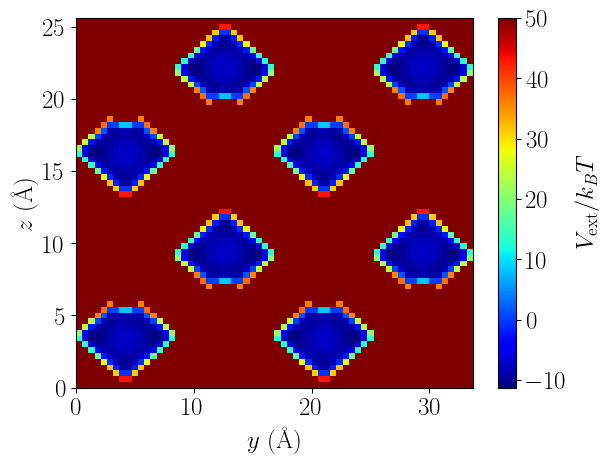

In [6]:
plt.rcParams.update({'text.usetex':True, 
'font.family':'serif', 
'font.size':18, 
# 'axes.linewidth':1.1, 
'lines.linewidth':1.6,
'legend.fontsize': 18,
'legend.frameon':False
#'figure.figsize':(7.9, 6.1)
})


plt.figure()
c=plt.pcolormesh(dft.Y[0,:,:].cpu(),dft.Z[0,:,:].cpu(),Vext[0,:,:].cpu()/T,vmax=50.0,cmap='jet')
plt.colorbar(label=r'$V_{\mathrm{ext}}/k_B T$')
plt.xlabel(r'$y$ (\AA{})')
plt.ylabel(r'$z$ (\AA{})')

In [7]:
P = torch.hstack((torch.arange(1e1,1e2,1e1), torch.arange(1e2,1e3,1e2), torch.arange(1e3,1e4,1e3), 
                  torch.arange(1e4,1e5,1e4), torch.arange(1e5,1e6,1e5)))
bulk_density = torch.empty_like(P)

eos = lj_eos(parameters, T)
bulk_density[0] = eos.density(P[0],'vap')
for i in range(1,len(P)):
    bulk_density[i] = eos.density(P[i],bulk_density[i-1])

In [8]:
dft.initial_condition(bulk_density[0],Vext)

Nads = torch.empty(len(P))
for i in range(len(P)):
    dft.equilibrium_density_profile(bulk_density[i],fmt='ASWB',solver='anderson',
                                    anderson_damping=0.1, anderson_mmax=10, tol=1e-6,logoutput=False)
    Nads[i] = dft.total_molecules
    print(dft.it,dft.error.numpy(),1e-5*P[i].numpy(),Nads[i].numpy())
    if np.isnan(dft.error.numpy()): break

6 2.4525216781102595e-10 0.0001 0.14505911843944483
6 1.8324125019302414e-08 0.0002 0.2902800663497854
6 5.470644204711002e-07 0.00030000000000000003 0.4356599125417228
5 7.016790000447857e-08 0.0004 0.5811966774801622
6 2.367882839090336e-08 0.0005 0.7268869724004651
6 6.321233337402791e-08 0.0006000000000000001 0.8727282802073378
5 4.242667129231856e-07 0.0007000000000000001 1.0187184404863574
5 3.810278428799482e-07 0.0008 1.1648538473360592
5 1.619778112523203e-07 0.0009000000000000001 1.3111320303548495
5 1.3196544854460713e-07 0.001 1.4575507202532385
8 3.659224568182579e-07 0.002 2.9288637415331458
7 2.576666892852845e-07 0.003 4.4112600939869795
7 8.778469528596472e-08 0.004 5.902042812740129
7 2.5717783267857006e-07 0.005 7.398501045474365
7 9.380476183053092e-07 0.006 8.89789016386858
9 7.119121218791556e-08 0.007 10.397419564294584
9 1.4218150711106535e-07 0.008 11.894295806543385
9 2.0107546869684868e-07 0.009000000000000001 13.385706184775241
9 3.96334338510264e-07 0.01 14

In [9]:
Ndes = torch.empty(len(P))
for i in reversed(range(len(P))):
    dft.equilibrium_density_profile(bulk_density[i],fmt='ASWB',solver='anderson',
                                    anderson_damping=0.1, anderson_mmax=10, tol=1e-6,logoutput=False)
    Ndes[i] = dft.total_molecules
    print(dft.it,dft.error.numpy(),1e-5*P[i].numpy(),Nads[i].numpy())
    if np.isnan(dft.error.numpy()): break

0 9.748450227854333e-07 9.0 159.91115303563615
32 8.645279596114586e-07 8.0 158.60494211505468
22 8.463745152294254e-07 7.000000000000001 157.05919339749823
34 9.468183311164973e-07 6.000000000000001 155.18527320344322
30 8.090787551025736e-07 5.0 152.83886758453863
30 8.530365787164362e-07 4.0 149.7641185114178
24 9.741238634650895e-07 3.0000000000000004 145.45044600415673
33 7.202623061581259e-07 2.0 138.67962773597372
18 6.349917093175773e-07 1.0 125.5151791393292
14 7.056508924609649e-07 0.9 123.40422495130227
15 7.007635000501812e-07 0.8 121.02895113098351
15 1.5827390900329193e-07 0.7000000000000001 118.32351450882325
14 3.962076142524779e-07 0.6000000000000001 115.19082836149951
15 4.6038436810423737e-07 0.5 111.47663535446532
15 3.5659385850376317e-07 0.4 106.91028101680853
15 2.9862631508269566e-07 0.30000000000000004 100.94537337849113
17 2.964326430299552e-08 0.2 92.20817151649513
16 3.1600744729166657e-07 0.1 75.45534844513777
12 2.5698152098844496e-07 0.09000000000000001 7

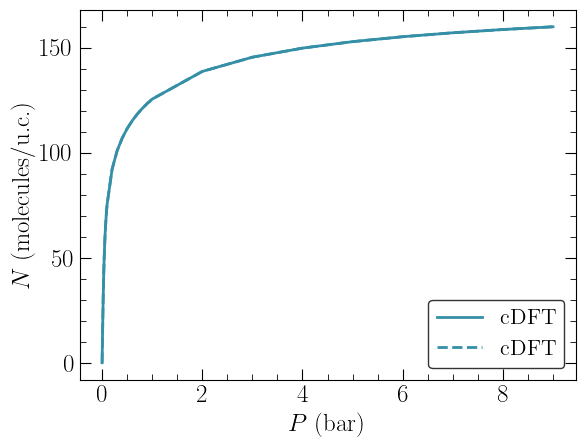

In [10]:
# data = pd.read_pickle(f'data/methane_IRMOF-1_{T:.2f}K.pkl')

import seaborn as sns

colors = sns.color_palette("mako")

plt.rcParams.update({'text.usetex':True, 
'font.family':'serif',  
#'figure.figsize':(7.9, 6.1)
})

plt.plot(P*1e-5, Nads, '-', color=colors[3], linewidth=2.0, label='cDFT')
plt.plot(P*1e-5, Ndes, '--', color=colors[3], linewidth=2.0, label='cDFT')
# plt.plot(1e-5*data['Pressure (Pa)'], data['Absolute adsorption (molecules/uc)'], 'o', 
#          color=colors[3],markersize=7,markeredgewidth=1.5,mfc='none',label='GCMC')
plt.xlabel(r'$P$ (bar)', fontsize=18)
plt.ylabel(r'$N$ (molecules/u.c.)', fontsize=18)
# plt.xlim([0.0,125])
# plt.ylim([None,0.004])
plt.minorticks_on()
plt.tick_params(direction='in',right=True, top=True)
plt.tick_params(labelsize=18)
plt.tick_params(labelbottom=True, labeltop=False, labelright=False, labelleft=True)
plt.tick_params(direction='in',which='minor', length=4, bottom=True, top=True, left=True, right=True)
plt.tick_params(direction='in',which='major', length=8, bottom=True, top=True, left=True, right=True)
plt.legend(fontsize=16, frameon=True, edgecolor='k')
# plt.savefig('figures/isotherm_methane.pdf', bbox_inches='tight')

Text(0, 0.5, '$y$ (\\AA{})')

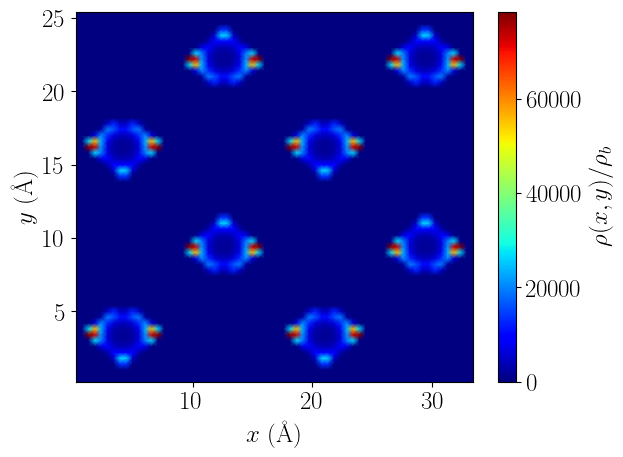

In [11]:
plt.figure()
c=plt.pcolormesh(dft.Y[0,:,:].cpu(),dft.Z[0,:,:].cpu(),dft.rho[0,:,:].cpu()/dft.rhob.cpu(),cmap='jet',shading='gouraud')
plt.colorbar(c, label=r'$\rho(x,y)/ \rho_b$')
plt.xlabel(r'$x$ (\AA{})')
plt.ylabel(r'$y$ (\AA{})')

In [ ]:
np.save('dft',dft.rho.cpu().numpy())